In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv(r"Crop_Recommendation.csv")
data

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,Coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,Coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,Coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,Coffee


# EXPLORATORY DATA ANALYSIS

In [3]:
data.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [4]:
data.tail()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,Coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,Coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,Coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,Coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,Coffee


In [5]:
data.isna().any()

Nitrogen       False
Phosphorus     False
Potassium      False
Temperature    False
Humidity       False
pH_Value       False
Rainfall       False
Crop           False
dtype: bool

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [7]:
data.duplicated().any()

np.False_

In [8]:
data.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


# VISUALISING DATA BY MATPLOTLIB

In [9]:
data1=data.drop(['Nitrogen','Phosphorus','Potassium','Temperature','Humidity','Rainfall',],axis=1)
data1

,pH_Value,Crop
0,6.502985,Rice
1,7.038096,Rice
2,7.840207,Rice
3,6.980401,Rice
4,7.628473,Rice
...,...,...
2195,6.780064,Coffee
2196,6.086922,Coffee
2197,6.362608,Coffee
2198,6.758793,Coffee


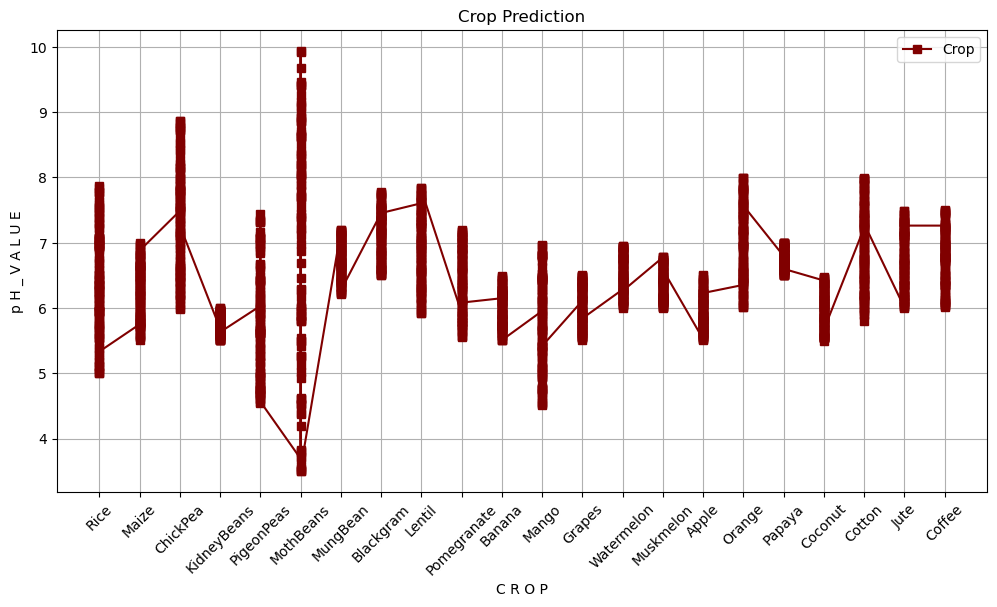

In [10]:
plt.figure(figsize=(12,6))
plt.plot(data['Crop'],data['pH_Value'],color='#800000',label='Crop',marker='s')
plt.xlabel('C R O P')
plt.ylabel('p H _ V A L U E')
plt.title('Crop Prediction')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [11]:
x=data.drop(['Crop'],axis=1)
y=data['Crop']

In [12]:
y

0         Rice
1         Rice
2         Rice
3         Rice
4         Rice
         ...  
2195    Coffee
2196    Coffee
2197    Coffee
2198    Coffee
2199    Coffee
Name: Crop, Length: 2200, dtype: object

In [13]:
x

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [14]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [15]:
ytrain

1102     Mango
1159     Mango
141      Maize
1004    Banana
2         Rice
         ...  
1638    Orange
1095    Banana
1130     Mango
1294    Grapes
860     Lentil
Name: Crop, Length: 1540, dtype: object

In [16]:
xtrain

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
1102,21,26,27,27.003155,47.675254,5.699587,95.851183
1159,29,35,28,28.347161,53.539031,6.967418,90.402604
141,60,44,23,24.794708,70.045567,5.722580,76.728601
1004,80,77,49,26.054330,79.396545,5.519088,113.229737
2,60,55,44,23.004459,82.320763,7.840207,263.964248
...,...,...,...,...,...,...,...
1638,10,5,5,21.213070,91.353492,7.817846,112.983436
1095,108,94,47,27.359116,84.546250,6.387431,90.812505
1130,11,36,31,27.920633,51.779659,6.475449,100.258567
1294,11,124,204,13.429886,80.066340,6.361141,71.400430


# MODEL FITTING

## LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [ ]:
model.fit(xtrain,ytrain)

In [ ]:
poi=model.predict(xtest)
poi

In [ ]:
Logistictrain=model.score(xtrain,ytrain)*100
Logistictrain

In [ ]:
Logistictest=model.score(xtest,ytest)*100
Logistictest

## DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model2=DecisionTreeClassifier()
model2.fit(xtrain,ytrain)

In [ ]:
DecisionTreetrain=model2.score(xtrain,ytrain)*100
DecisionTreetrain

In [ ]:
DecisionTreetest=model2.score(xtest,ytest)*100
DecisionTreetest

## RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier(n_estimators=100)
model3.fit(xtrain,ytrain)

In [ ]:
RandomForesttrain=model3.score(xtrain,ytrain)*100
RandomForesttrain

In [ ]:
RandomForesttest=model3.score(xtest,ytest)*100
RandomForesttest

## AdaBoostClassifier

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model4=AdaBoostClassifier(n_estimators=50)
model4.fit(xtrain,ytrain)

In [ ]:
AdaBoosttrain=model4.score(xtrain,ytrain)*100
AdaBoosttrain

In [ ]:
AdaBoosttest=model4.score(xtest,ytest)*100
AdaBoosttest

## GradientBoostingClassifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model5=GradientBoostingClassifier(n_estimators=50)
model5.fit(xtrain,ytrain)

In [ ]:
GradientBoostingtrain=model5.score(xtrain,ytrain)*100
GradientBoostingtrain

In [ ]:
GradientBoostingtest=model5.score(xtest,ytest)*100
GradientBoostingtest

## KNeighborsClassifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model6=KNeighborsClassifier(n_neighbors=5)
model6.fit(xtrain,ytrain)

In [ ]:
KNeighborstrain=model6.score(xtrain,ytrain)*100
KNeighborstrain

In [ ]:
KNeighborstest=model6.score(xtest,ytest)*100
KNeighborstest

## GaussianNB

In [ ]:
from sklearn.naive_bayes import GaussianNB
model7=GaussianNB()

In [ ]:
model7.fit(xtrain,ytrain)

In [ ]:
Gaussiantrain=model7.score(xtrain,ytrain)*100
Gaussiantrain

In [ ]:
Gaussiantest=model7.score(xtest,ytest)*100
Gaussiantest

# PREDICTION

In [ ]:
Nitrogen=int(input("Enter the Nitrogen"))
Nitrogen

In [ ]:
Phosphorus=int(input("Enter the Phosphorus"))
Phosphorus

In [ ]:
Potassium=int(input("Enter the Potassium"))
Potassium

In [ ]:
Temperature=float(input("Enter the Temperature"))
Temperature

In [ ]:
Humidity=float(input("Enter the Humidity"))
Humidity

In [ ]:
pH_Value=float(input("Enter the pH_Value"))
pH_Value

In [ ]:
Rainfall=float(input("Enter the Rainfall"))
Rainfall

In [ ]:
print(model3.predict([[Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall]]))

# BUILD GRADIO INTERFACE

In [ ]:
!pip3 install gradio

In [ ]:
def fun(Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall):
    pred = model3.predict([[Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall]])
    return pred

In [ ]:
import gradio as gr

In [ ]:
headline ="Crop prediction App"
iface = gr.Interface(fn=fun,inputs=[
        gr.Textbox(label="Nitrogen"),
        gr.Textbox(label="Phosphorus"),
        gr.Textbox(label="Potassium"),
        gr.Textbox(label="Temperature"),
        gr.Textbox(label="Humidity"),
        gr.Textbox(label="pH_Value"),
        gr.Textbox(label="Rainfall")],
        outputs=[gr.Textbox(label="Crop")],title=headline,css=".gradio-container {background-color:brown}")
iface.launch(share=True)